# Practicum 1

By submitting this notebook to Gradescope you are acknowledging that you are upholding the Duke honor code that this notebook is representative of the work of all that are on the submission and no one else.

This assessment can be done in teams of two. It represents your pair's work, and only your pair's work to show your all's understanding of the material. This document and your answers are for your pair's eyes only.

This exam is open book, open note, open Internet, open to large language models, and closed to people outside of your team. This means you cannot communicate with someone outside of your pair about the practicum until grades are published, including asking someone through the Internet (like stackoverflow) to receive help.

If you wish to earn an Exemplary (full credit), your plots must be clean and easy to understand. That means ensuring the text of axis labels are not overlapping by using parameters like `aspect` and `height`. Using column names as your axis labels is fine and titles are not required. **In addition, all answers that are clearly plagiarized from the practice exam will be marked as Not Yet**. 

You **may reuse** the results of prior questions (like variables or new columns) in later questions. If you do so, you need to clearly state it for the graders.

Except for the Monte Carlo Simulation problem (question 4), you may **not use** `for` or `while` loops if there are clear ways to do it using libraries and without such loops. In addition, the code must guarantee that the loop will iterate less than 25 times, including if we swap out the data for another data file with 10x more rows. Using such loops will immediately mark your solution as "Not Yet" because one large purpose of this exam is to assess your skills at taking advantage of the data science libraries.

If you think something is ambiguous or some assumption/key information is missing, decide on your own interpretation or any additional assumption and state them clearly.

The grading for this exam will be very lenient in the reasonableness of how you use the data since we do not expect you to have a great understanding of the data set. Moreover, the values in this data set do not necessarily reflect the real world.

# Practicum Update Diff Cell (2 points, if you submit the Update)
If you are not updating your practicum for the Practicum Update, ignore this cell. If you are updating this notebook for the Practicum Update, fill out this template to make clear what you did and did not change.

### Question 1
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question, for example something like "We did not change the code and only changed the writeup to better answer questions 2 and 3.")

### Question 2
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question, for example something like "We cleaned up the code by removing the `==True` and did not change the writeup.")

### Question 3
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question)

### Question 4
- updated = ...
- summary: None (replace with your summary if you updated your answer for this question)

# Overview Note

We recommend scanning through the entire exam before beginning so you have a sense of what each question is asking you to do.

Feel free to add columns to the dataframe and use them throughout the notebook. Just note in your writeup where the code for a particular new column is to make grading easier.

**Using LLMs**: For each question, there is a variable called `q#_llm_flag`. Set this to `True` if you used an LLM to help you with that question and `False` otherwise.

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt

# Group Members

In the below cell provide the NetIds as strings of all the people working on this practicum. If you are working solo, write `student2`'s NetId as `'no1'`.

In [2]:
student1 = 'kdf32'
student2 = 'mdm144'

# Data Set: AirBnB Listings

Below is a data set about AirBnB listings in North Carolina. Every row represents a single AirBnB listing.

The meanings of all columns are listed below.

Note: The values in this data set do not necessarily reflect the real world and may be inaccurate.

| Variable | Type | Description |
|----------|------|-------------|
| `id` | int64 | ID for the listing |
| `name` | str | Name of the listing |
| `description` | str | Description of the listing |
| `neighborhood_overview` | str | Overview of the neighborhood the listing is in |
| `host_id` | int64 | ID for the host |
| `host_name` | str | Host's name, could be one or more people, or a company |
| `host_since` | str | Date since being a host |
| `host_location` | str | Where the host is from with format "City, State", state is the state abbreviation |
| `host_about` | str | Description about the host |
| `host_response_time` | str | How quickly the host responds; 4 possible options |
| `host_response_rate` | str | Percent of times host responds as a string |
| `host_acceptance_rate` | str | Percent of times host accepts a booking as a string |
| `host_is_superhost` | bool | Whether the host is a super host |
| `host_listings_count` | int64 | Number of listings the host has in NC |
| `host_total_listings_count` | int64 | Number of listings the host has total |
| `host_has_profile_pic` | bool | Whether the host has a picture in their profile |
| `host_identity_verified` | bool | Whether the host's identity has been verified |
| `neighbourhood` | str | Where the listing is with format "City, State, Country", state is the full state name |
| `neighbourhood_zip` | int64 | The neighborhood's zip code |
| `latitude` | float | Listings latitude |
| `longitude` | float | Listings longitude |
| `property_type` | str | Type of property, not standardized; there are many possible options |
| `room_type` | str | Type of room, 4 possible options |
| `accommodates` | int64 | How many people the listing can have |
| `bathrooms_text` | str | Text description of the bathrooms |
| `bedrooms` | float | Number of bedrooms |
| `beds` | float | Number of beds |
| `amenities` | str | Python formatted list of amenities with no particular order |
| `price` | str | Price of one night as a string |
| `minimum_nights` | int64 | Minimum number of nights for a booking |
| `maximum_nights` | int64 | Maximum number of nights for a booking |
| `availability_365` | int64 | Number of days available throughout the year |
| `review_scores_rating` | float | Mean general rating |
| `review_scores_accuracy` | float | Mean rating about the listing's accuracy |
| `review_scores_cleanliness` | float | Mean rating about the listing's cleanliness |
| `review_scores_checkin` | float | Mean rating about the listing's checkin experience |
| `review_scores_communication` | float | Mean rating about the listing's communication with the host |
| `review_scores_location` | float | Mean rating about the listing's location |
| `review_scores_value` | float | Mean rating about the listing's value |
| `instant_bookable` | bool | Whether the listing is instantly bookable |
| `calculated_host_listings_count` | int64 | A different calculated count of the number of listings by the host |
| `calculated_host_listings_count_entire_homes` | int64 | How many entire homes the host lists |
| `calculated_host_listings_count_private_rooms` | int64 | How many private rooms the host lists |
| `calculated_host_listings_count_shared_rooms` | int64 | How many shared rooms the host lists |

In [3]:
# import data
df = pd.read_csv('listings.csv')
print(df.shape)
df.head()

(3161, 44)


,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,108061,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...,"I love my neighborhood! Its friendly, easy-goi...",320564,Lisa,2010-12-16,"Asheville, NC",I am a long time resident of Asheville and am ...,within an hour,...,4.70,4.85,4.80,4.84,4.49,False,2,2,0,0
1,155305,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Pet friendly private cot...,"We are within easy walk of pubs, breweries, mu...",746673,BonPaul,2011-06-26,"Asheville, NC",We operate two traveler's hostels located in H...,within an hour,...,4.42,4.83,4.74,4.93,4.55,False,6,1,2,3
2,156805,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...,"Easy walk to pubs, cafes, bakery, breweries, l...",746673,BonPaul,2011-06-26,"Asheville, NC",We operate two traveler's hostels located in H...,within an hour,...,4.43,4.76,4.61,4.84,4.46,True,6,1,2,3
3,197263,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ...",NaN,961396,Timo,2011-08-12,"Asheville, NC","I'm from Asheville, NC. I'm a yogi, artist and...",within a few hours,...,5.00,4.95,4.92,4.82,4.98,False,2,1,1,0
4,209068,Terrace Cottage,Located in one of Asheville's oldest historic ...,Our beautiful Grove Park Historic District clo...,1029919,Kevin,2011-08-28,"Asheville, NC",Welcome to Terrace Cottage!\r\n\r\nFor fifteen...,within a few hours,...,4.84,5.00,4.98,4.93,4.77,False,1,1,0,0


# Question 1 (24 points: 4 autograded, 20 manually graded)

Do the following:
1. Create a mask that you will use to filter the data:
    1. It must be True for 10%-90% of the data and False otherwise.
    1. You may base the mask on multiple columns, but you do not have to.
    1. Add the mask as a new column to the dataframe.
    1. Put the new column's name in `new_mask_col_name`.
1. Put the fraction of rows kept by the mask in `frac_data_kept`.
1. Use the mask to filter the data and then calculate a single descriptive statistic (e.g., mean, count, median, proportion, etc.) of a **different** column. Put this value in `statistic_mask`.
1. Calculate the same descriptive statistic for the entire data set.  Put this value in `statistic_all`.

**See the written portion of this question to see what you must explain.**

## Answer 1: Code

In [4]:
q1_llm_flag = False

new_mask_col_name = "more_than_three_beds"

df[new_mask_col_name] = df["beds"] > 3

frac_data_kept = df[df[new_mask_col_name]].shape[0] / df.shape[0]

filteredDF = df[df[new_mask_col_name]]
statistic_mask = filteredDF["review_scores_cleanliness"].mean()
statistic_all = df["review_scores_cleanliness"].mean()


# Leave these here to help with grading.
print("New mask's column name:", new_mask_col_name)
print('Fraction of data kept:', frac_data_kept)
print('Descriptive statistic of masked data:', statistic_mask)
print('Descriptive statistic of all data:', statistic_all)

New mask's column name: more_than_three_beds
Fraction of data kept: 0.20468206263840558
Descriptive statistic of masked data: 4.869781144781144
Descriptive statistic of all data: 4.894794238683128


<!-- BEGIN QUESTION -->

## Answer 1: Written portion
Do the following:
1. Explain what your mask is filtering for.
1. State the values of and what your descriptive statistics in `statistic_mask` and `statistic_all` are. Explain what these numbers tell you about the data. Are their values surprising? Why or why not?
1. If you did not in the prior subquestions, compare the two values, is one bigger? Which one? Speculate why this is the case.

1. The mask more_than_three_beds filters for AirBnB listings with more than three beds.
2. The value in statistic_mask is the mean cleanliness score across listings for which there are more than three beds, which is 4.870. The value in statistic_all is the mean cleanliness score across all listings, which is 4.895. These values suggest that listings with more than three beds are rated as less clean, on average, compared to the mean cleanliness rating across all listings. This result is not surprising, as listings with more beds are presumably larger and therefore harder to keep clean. 
3. As described above, the value statistic_all is larger than statistic_mask. This is likely because listings with more beds are presumably larger and therefore harder to keep clean.

<!-- END QUESTION -->

# Question 2 (25 points: 4 autograded, 21 manually graded)

Assessment goal: Demonstrate an understanding of how to use regular expressions to extract information from strings that are irregular.

Do the following:
1. Use a regular expression(s) to create a new column by extracting information (a substring or number) from an existing column with data of type string.
    1. The existing/original column must have more than 18 unique values. So, do not use something like `room_type`.
    1. The extracted information cannot be from something that is extremely uniform, such as something that is of fixed width and in the same location, like removing "North Carolina" from `neighbourhood` or the `$` from `price`. If you could get it by just slicing all the strings the same way, it is not a good demonstration of using regular expressions.
    1. The extracted information must be information that cannot easily be extracted with methods other than regular expressions (such as creating a `True`/`False` or `"yes"`/`"no"` column by just using `str.contains` or equivalent).
    1. Therefore, the extracted information must be a number or of type string.
    1. Put the name of the column you are extracting from in `org_col_name`.
    1. Put the new column's name in `new_col_name`.
1. Count the number of NaNs in **the original column** and put it in `nan_count_org`.
1. Count the number of NaNs in **your new column** and put it in `nan_count_new`.

**See the written portion of this question to see what you must explain.**

## Answer 2: Code

In [5]:
q2_llm_flag = False

org_col_name = "description"
new_col_name = "square-footage"

regex = r'(?:~)?\s*(\d+,?\d*\.?\d*)\s*(?:sq\.?\s*ft\.?|sqft|square\s*(?:foot|feet)\b|sf)\b'
df[new_col_name] = df[org_col_name].str.extract(regex, flags=re.IGNORECASE)
df[new_col_name] = df[new_col_name] .str.replace(",", "", regex=False).astype(float)

nan_count_org = df[org_col_name].isna().sum()
nan_count_new = df[new_col_name].isna().sum()


# Leave these here to help with grading.
print('Original column:', org_col_name)
print('Unique values in original column:', df[org_col_name].nunique())
print('New column:', new_col_name)
print('Head of old column:')
print(df[org_col_name].head(5))
print('Head of the non-NaN values of the new column:')
print(df[new_col_name].dropna().head(5))
print('Count of NaNs in original column:', nan_count_org)
print('Count of NaNs in new column:', nan_count_new)
print('% NaNs in new column:', 100*nan_count_new/df.shape[0])

Original column: description
Unique values in original column: 3106
New column: square-footage
Head of old column:
0    Walk to town in ten minutes! Monthly rental in...
1    <b>The space</b><br />Pet friendly private cot...
2    <b>The space</b><br />Private Rooms at Bon Pau...
3    This is a comfy, peaceful and clean room with ...
4    Located in one of Asheville's oldest historic ...
Name: description, dtype: object
Head of the non-NaN values of the new column:
39     600.0
66     235.0
78    1400.0
86    1000.0
93    1900.0
Name: square-footage, dtype: float64
Count of NaNs in original column: 8
Count of NaNs in new column: 2858
% NaNs in new column: 90.41442581461563


<!-- BEGIN QUESTION -->

## Answer 2: Written portion
Do the following:
1. Explain what the code you wrote in the code cell does.
1. State how many NaNs there are in the original and new columns. Provide a possible reason why the NaNs are/are not there.
1. If you did not discuss this in the prior subquestion, why do the original and new columns have the same or not the same number of NaNs?

1. The column square-footage contains the square footage of each listing if it can be found from the listing description and NaN if it cannot. This is found using the following regex structure in a case-insensitive manner and stored in the new column:
- Optional ~ and/or space before the number
- Capture a number, possibly interrupted by a comma and/or period
- Must have some indication of square feet, including but not limited to: square foot, square feet, sqft, sq. ft.
- The captured value is stored as a string, which may contain commas. The commas are then removed and the values are typecast into floats.
2. There are 8 instances of NaN in the original column and 2858 instances in the new column. NaN in the original column indicates that this listing does not have a description. NaN in the new column indicates that there are no discoverable values for the square footage of this listing from the description. Any listing with a value of NaN in the original column will have a value of NaN in the new column. New instances of NaN arise due to either 1. the square footage not being listed in the description 2. the square footage being listed in a way that is not compatible with the regex. 
3. The original and new columns do not have the same number of NaNs because many listings have descriptions but do not have discoverable square footage values listed in them. 

<!-- END QUESTION -->

# Question 3 (25 points: 4 autograded, 21 manually graded)

For this question, do the following:

1. `col_cat` column - Create a new column that labels each row with some kind of category. Put the name of your new column in `col_cat`. Other requirements include:
   1. The column needs at least 2 categories and cannot have more than 18.
   1. You may use the results of the regular expression question, just state as much in the write up.
   1. If you wish, you may filter to reduce the number of categories or the data you are visualizing. For example, you can filter to make your plot more legible. You must have at least 100 rows in the dataframe you use to create your plot.
1. Put in `val_counts` a Series where the key/index are the categories of `col_cat` and the values are the number of rows with that category.
1. Use `relplot`, `displot`, or `catplot` to create a plot using the `col_cat` column and **at least one other column** ([documentation figure](https://seaborn.pydata.org/tutorial/function_overview.html#figure-level-vs-axes-level-functions "‌")).
1. Put the data you used for the plot in `table3`. This table should include **only** the data you used and no other columns nor rows.

**Note**: Remember, your plot must be legible to be able to earn an Exemplary mark.

**See the written portion of this question to see what you must explain.**

## Answer 3: Code

Shape of dataframe: (3161, 2)
At least 100 rows in data?: True
Columns: Index(['stay_type', 'price_ft'], dtype='object')
Number of unique values in stay_type column: 8
Number of categories within range? True
Counts of stay_type categories:
stay_type
Large Entire Space      1110
Medium Entire Space      936
Small Entire Space       703
Small Private Space      331
Medium Private Space      62
Large Private Space       12
Small Shared Space         5
Medium Shared Space        2
Name: count, dtype: int64


,stay_type,price_ft
0,Small Entire Space,100.0
1,Small Entire Space,100.0
2,Small Private Space,66.0
3,Small Private Space,45.0
4,Medium Entire Space,100.0


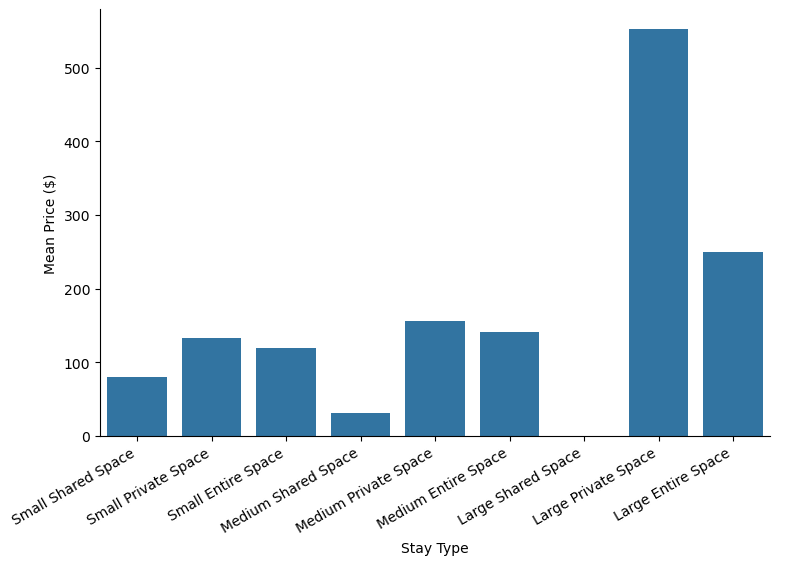

In [6]:
q3_llm_flag = False

# Using accommodates and room_type

col_cat = "stay_type"
df[col_cat] = np.nan

a = df["accommodates"]
rt = df["room_type"]

df.loc[a <= 2, "size"] = "Small"
df.loc[(a > 2) & (a <= 4), "size"] = "Medium"
df.loc[a > 4, "size"] = "Large"

df.loc[rt == "Entire home/apt", "priv"] = "Entire Space"
df.loc[rt.isin(["Private room", "Hotel room"]), "priv"] = "Private Space"
df.loc[rt == "Shared room", "priv"] = "Shared Space"

df[col_cat] = df["size"] + " " + df["priv"]

df.drop(columns=["size", "priv"], inplace = True)

df["price_ft"] = (df["price"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float))

table3 = df[[col_cat, "price_ft"]].dropna().copy()

val_counts = table3[col_cat].value_counts()

# There should be at least one call to a seaborn function
# sns.?

sns.catplot(
    data = table3,
    x = col_cat,
    y = "price_ft",
    kind = "bar",
    aspect = 1.5,
    errorbar = None,
    order = ["Small Shared Space", "Small Private Space", "Small Entire Space", 
             "Medium Shared Space", "Medium Private Space", "Medium Entire Space", 
             "Large Shared Space", "Large Private Space", "Large Entire Space"]
)
plt.xlabel("Stay Type")
plt.ylabel("Mean Price ($)")
plt.xticks(rotation=30, ha="right")

# Leave these here to help with grading.
print('Shape of dataframe:', table3.shape)
print('At least 100 rows in data?:', table3.shape[0] >= 100)
print('Columns:', table3.columns)
print('Number of unique values in', col_cat, 'column:', table3[col_cat].nunique())
print('Number of categories within range?', 2 <= table3[col_cat].nunique())
print('Counts of', col_cat, 'categories:')
print(val_counts[:15])
table3.head()

<!-- BEGIN QUESTION -->

## Answer 3: Written portion
Explain the following:
1. What is the code doing? Include:
    1. What is `col_cat`? What do the categories in it mean? How did you create it?
    1. How you filtered and why you chose to keep the data you did. If you did not filter at all, just state as much.
1. Explain generally what the plot is showing.
1. Pick a single spot on the plot and describe it by filling out the sentence "The \_\_ on the chart means \_\_ ." (you may use these exact words)
    1. Make sure it is clear what spot you are referring to and you are "pointing" it out without using its data values (otherwise, that's like defining a word while using the word in the definition). For example, "the top right blue dot" or "the shortest red bar," as opposed to "the top dot for AirBnBs that are Private rooms."
    1. If using something like a histogram, be precise about what is inclusive vs. exclusive. For example, “it includes up to 10” is not the same as “it includes up to and including 10.”
    1. If using a boxplot, make sure to mention multiple lines/parts of the boxes and note any outliers.
1. Why did you choose `relplot`/`displot`/`catplot` and use any deviations from the default behavior of that function? Discuss this at least partially in terms of the insight you sought from the plot.
1. Why the other `seaborn` functions would have been less useful to show you what you wanted to see OR why they are equally viable?

1.
    1. `col_cat` is a categorical variable that stores the name `"stay_type"`, a column name. This column categorizes each Airbnb listing based on the two characteristics: that being how many guests that stay accommodates, and the type of room listed. These came from `accommodates` and `room_type` columns respectively. It was created using the following process:
    The listings in `accommodates` column would then be divided into three size groups based on how many people that listing accommodates, that being *Small* for 1-2 guests, *Medium* for 3-4 guests, and *Large* for 5 or more guests.
    The listings in `room_type` would follow, being grouped into three groups based on their nature of their privacy. A room would be categorized an *Entire Space* if it was an entire home or apartment, a *Private Space* if it was a private room or hotel room, and a *Shared Space* if it was a shared room.
    Each listing would then be categorized under a combination of these two groupings, such as "Small Private Space," or "Large Entire Space."
    2. I filtered my data by removing rows with any missing values. I additionally created new temporary columns to construct that category that were later removed after creating my new column.

2.
    The plot shows the mean price of Airbnb listings for each category of `stay_type`, where `stay_type` is a unique combination of room size and privacy. 
3.
    The tallest blue bar on the chart, second from the right, represents that listings categorized as a "Large Private Space" (5+ guests, private/hotel room) have the highest mean price among all the other categories at around $560.
4.
    I chose `sns.catplot(kind = "bar")` because my indepedent variable `stay_type` is categorical and my dependent variable `price_ft` is numerical. This is because a bar chart is a visualization used to observe and compare different categories of data. Since I wished to observe the mean price of data types across the six categories, a bar chart was an optimal choice. Deviating from original behavior, I removed the default error bars `(errorbar = None)` to improve both visual clarity as well as rotating the x-axis labels to allow for readability due to the length of their names.
5.
    Both Seaborn's `relplot` and `displot` would be less useful in visualizing both categorical data as well as presenting side-by-side comparison optimally. `sns.catplot(kind = "box")` would be potentially more useful in observing distribution spread across categories, including outliers. However in attempting to utilize that visualization prior to a bar chart, it was noticed that the quantity of outliers and generally high distribution of each category's data made observation less legible.


<!-- END QUESTION -->

# Question 4 (25 points: 4 autograded, 21 manually graded)

In this question, you will run a Monte Carlo Simulation. Your code will sample a subset of listings. Describe a scenario and then calculate the probability of that scenario happening with the following constraints:
1. Use at least 2 columns of data as part of your scenario.
1. The scenario should have some kind of inequality in it, such as "The mean cost of AirBnBs in Fletcher is more than Asheville."
1. The scenario should involve more than one AirBnB.
1. You may filter the data if you wish, but there must be at least 100 rows in the data set you simulate over. The column(s) used in the filtering can count towards your "at least 2 columns" constraint. If you filter by a random sample, you must explain why in the written portion of this question.
1. Run enough simulations that you are confident in your answer within 0.1% (this code prints things as a decimal, so 0.1% is the third digit after the decimal). Do not change the `count` and `sims` variable names. The autograder uses these to do its sanity check.

**See the written portion of this question to see what you must explain.**

**Note**: You are allowed to use a `for` or `while` loop for this question.

## Answer 4: Code

In [7]:
q4_llm_flag = False

df["host_rate_ft"] = (df["host_acceptance_rate"].str.replace("%", "", regex=False).str.replace(",", "", regex=False).astype(float))

airbnb = df[df["instant_bookable"] == True].reset_index(drop=True)


# Add and update whatever code you need into this skeleton
count = 0
sims = 50000

sample_size = 10
host_accept = 90
min_accept_count = int(np.ceil(sample_size * 0.75))

for i in range(sims):
    sample = airbnb.sample(sample_size, replace=False)
        
    accept_count = (sample["host_rate_ft"] > host_accept).sum()

    if accept_count >= min_accept_count:
        count += 1
    
    # Leave this if statement here for grading to show you
    # are confident in your answer within 0.1%
    if (i+1) % 1000 == 0:
        print(i+1, count/(i+1))


# Leave this here to help with grading.
print('Final result:', count/sims)

1000 0.988
2000 0.986
3000 0.985
4000 0.98525
5000 0.985
6000 0.9853333333333333
7000 0.9857142857142858
8000 0.986
9000 0.9856666666666667
10000 0.9857
11000 0.986
12000 0.98575
13000 0.9854615384615385
14000 0.9859285714285714
15000 0.9860666666666666
16000 0.9858125
17000 0.9858823529411764
18000 0.9861666666666666
19000 0.9856842105263158
20000 0.98585
21000 0.985904761904762
22000 0.9860454545454546
23000 0.9860869565217392
24000 0.9863333333333333
25000 0.9864
26000 0.9863846153846154
27000 0.9865555555555555
28000 0.9865714285714285
29000 0.9866896551724138
30000 0.9865333333333334
31000 0.9866451612903225
32000 0.9868125
33000 0.9868787878787879
34000 0.9869117647058824
35000 0.9869714285714286
36000 0.9869722222222223
37000 0.9868378378378379
38000 0.987
39000 0.9871282051282051
40000 0.9872
41000 0.9870975609756097
42000 0.987
43000 0.9870930232558139
44000 0.9869318181818182
45000 0.9870888888888889
46000 0.9870869565217392
47000 0.987
48000 0.9870416666666667
49000 0.986877

<!-- BEGIN QUESTION -->

## Answer 4: Written portion
Do the following:
1. Provide a 1-3 sentence explanation of the scenario. Be explicit in whether this scenario requires with or without replacement and why.
1. State the probability your simulation found, rounded to the nearest 0.1%, and explain why you are confident in your answer.

1.
    My scenario investigates whether a random sample of 10 Airbnb listings without replacement satisfies the condition that 75% have a `host_acceptance_rate` above 90%. I use `instant_bookable` to filter the initial population of listings and `host_acceptance_rate` to test the event. Sampling without replacement was used because a group of 10 distinct listings chosen from the data is being modeled, in order to reflect chosing 10 different Airbnb listings each time; this wouldn't make sense if a listing could be selected multiple times.

2.
    The simulation found a probability of roughly 98.7%. This is a confident answer because in running 50,000 simulations, a standard error of approximately 0.0005066 was achieved, which is less than the well below 0.001, the standard error required.

<!-- END QUESTION -->

# AI Disclosure (1 point)
Use the [Artificial Intelligence Disclosure (AID) Framework](https://crln.acrl.org/index.php/crlnews/article/view/26548/34482) to explain your use of AI on this exam. Keep in mind the other examples on the class's policy web page.

## My AI Disclosure

*Artificial Intelligence Tools*: AI was not used in the completion of this assignment.

## Submitting

You should make sure any code that you write to answer the questions is included in this notebook. You are **strongly encouraged** to go to the Kernel option and choose **"Restart & Run All"**  before submission. Double check that your entire notebook runs correctly and generates the expected output. Finally, make sure to save your work (timestamp at the top tells you the last checkpoint and whether there are unsaved changes). When you finish, submit your assignment at [Gradescope](http://gradescope.com/ "‌"). **Submissions not prepared correctly as above may lose points.**